<a href="https://colab.research.google.com/github/mohanbaskaran7373-jpg/fraud-detection/blob/main/fraud_detection_using_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Evaluating K-Means for k=2 to 10...
Converged after 3 iterations
Converged after 3 iterations
Converged after 3 iterations
Converged after 15 iterations
Converged after 15 iterations
Converged after 15 iterations
Converged after 15 iterations
Converged after 15 iterations
Converged after 15 iterations
Converged after 15 iterations
Converged after 15 iterations
Converged after 15 iterations
Converged after 11 iterations
Converged after 11 iterations
Converged after 11 iterations
Converged after 13 iterations
Converged after 13 iterations
Converged after 13 iterations
Converged after 14 iterations
Converged after 14 iterations
Converged after 14 iterations
Converged after 19 iterations
Converged after 19 iterations
Converged after 19 iterations
Converged after 11 iterations
Converged after 11 iterations
Converged after 11 iterations
Best k (Silhouette): 2 (Score: 0.836)
Best k (ARI): 2 (Score: 1.000)
Converged after 3 iterations
Detailed Results Table:
    k  Silhouette     ARI   Inertia

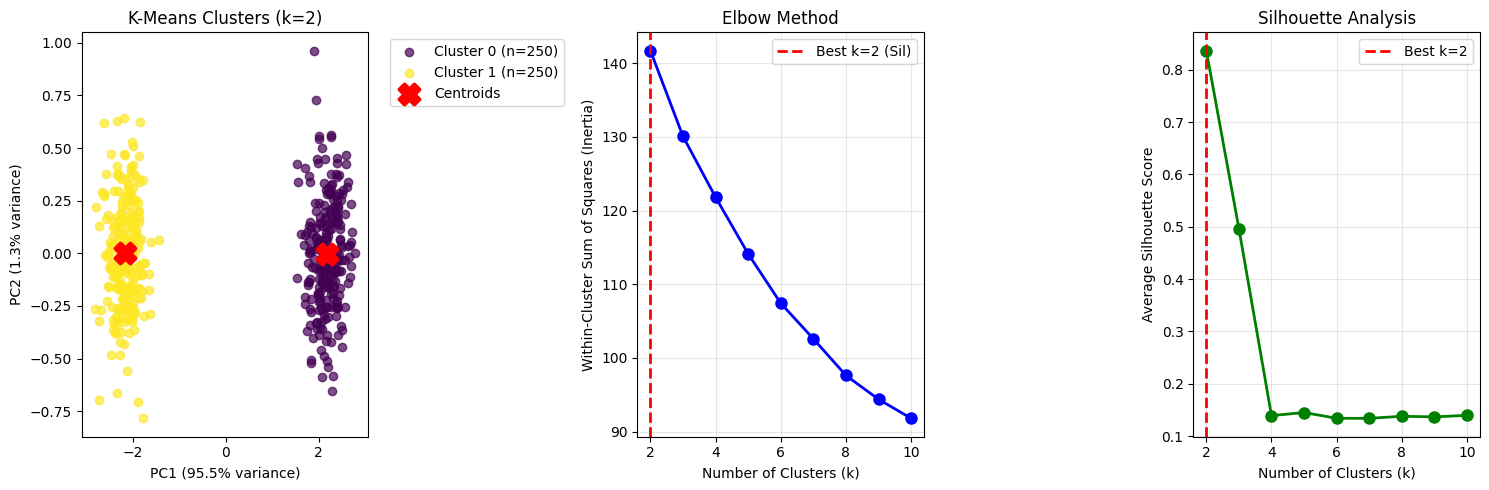

Final Model Summary:
- Best k (Silhouette): 2
- Silhouette Score: 0.836
- ARI Score: 1.000
- Inertia: 141.70
- Convergence: Achieved with K-Means++ initialization


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, euclidean_distances, adjusted_rand_score
np.random.seed(42)

# TASK 1: Generate synthetic dataset (500 samples, 5 features, 2 distinct clusters)
n_samples = 500
true_labels = np.array([0]*250 + [1]*250)  # Step 1: Add true labels for evaluation
X = np.concatenate([np.random.normal([2,2,2,2,2], 0.5, (250,5)),
                    np.random.normal([-2,-2,-2,-2,-2], 0.5, (250,5))])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# TASK 2: Improved K-Means from scratch implementation
class KMeansScratch:
    def __init__(self, n_clusters=5, max_iter=300, random_state=42, init='random'):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.random_state = random_state
        self.init = init  # Step 4: Add initialization method parameter
        self.centroids = None
        self.labels_ = None
        self.inertia_ = None

    def fit(self, X):
        np.random.seed(self.random_state)

        # Improved initialization (Step 4: K-Means++ option)
        if self.init == 'kmeans++':
            self.centroids = self._kmeans_plus_plus_init(X)
        else:
            idx = np.random.choice(X.shape[0], self.n_clusters, replace=False)
            self.centroids = X[idx]

        prev_inertia = float('inf')
        for i in range(self.max_iter):
            # Assignment step
            distances = euclidean_distances(X, self.centroids)
            self.labels_ = np.argmin(distances, axis=1)

            # Update step
            new_centroids = np.array([X[self.labels_ == k].mean(0)
                                    if np.sum(self.labels_ == k) > 0 else self.centroids[k]
                                    for k in range(self.n_clusters)])

            # Step 2: Check convergence properly using inertia change
            current_inertia = np.sum((X - self.centroids[self.labels_])**2)
            if abs(prev_inertia - current_inertia) < 1e-6:  # Proper convergence check
                print(f"Converged after {i+1} iterations")
                break
            prev_inertia = current_inertia

            self.centroids = new_centroids

        self.inertia_ = np.sum((X - self.centroids[self.labels_])**2)
        return self

    def _kmeans_plus_plus_init(self, X):
        """K-Means++ initialization (Step 4 improvement)"""
        centroids = [X[np.random.randint(0, X.shape[0])]]
        for _ in range(1, self.n_clusters):
            # Corrected: Renamed variables to avoid NameError and shadowing
            dists = np.array([min([np.sum((data_point - current_centroid)**2) for current_centroid in centroids]) for data_point in X])
            probs = dists / dists.sum()
            centroids.append(X[np.random.choice(X.shape[0], p=probs)])
        return np.array(centroids)

# TASK 3 & 4: Elbow + Silhouette evaluation (run 3 times, find best k)
sil_scores = {k: [] for k in range(2, 11)}
inertias = []
ari_scores = []  # Step 5: Add ARI for true label comparison

print("Evaluating K-Means for k=2 to 10...")

for k in range(2, 11):
    scores = []
    aris = []
    inertia_val = 0
    for seed in [42, 123, 456]:
        np.random.seed(seed)
        kmeans = KMeansScratch(n_clusters=k, init='kmeans++')  # Step 4: Use K-Means++
        kmeans.fit(X_scaled)
        scores.append(silhouette_score(X_scaled, kmeans.labels_))
        aris.append(adjusted_rand_score(true_labels, kmeans.labels_))  # Step 5: ARI metric
        inertia_val = kmeans.inertia_
    sil_scores[k] = np.mean(scores)
    ari_scores.append(np.mean(aris))
    inertias.append(inertia_val)

best_k_sil = max(range(2, 11), key=lambda k: sil_scores[k])
best_k_ari = max(range(2, 11), key=lambda k: ari_scores[k-2])
print(f"Best k (Silhouette): {best_k_sil} (Score: {sil_scores[best_k_sil]:.3f})")
print(f"Best k (ARI): {best_k_ari} (Score: {ari_scores[best_k_ari-2]:.3f})")

# TASK 5 & 6: 2D scatter plot with clusters colored + detailed table
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)

np.random.seed(42)
kmeans_final = KMeansScratch(n_clusters=best_k_sil, init='kmeans++')
kmeans_final.fit(X_scaled)

# Create detailed results table (Step 6 & 7)
results_df = pd.DataFrame({
    'k': range(2, 11),
    'Silhouette': [sil_scores[k] for k in range(2, 11)],
    'ARI': ari_scores,
    'Inertia': inertias
})
results_df['Best_Sil'] = results_df['k'] == best_k_sil
results_df['Best_ARI'] = results_df['k'] == best_k_ari

print("Detailed Results Table:")
print(results_df.round(4))

# Plotting
plt.figure(figsize=(15, 5))

# Cluster visualization
plt.subplot(1, 3, 1)
colors = plt.cm.viridis(np.linspace(0, 1, best_k_sil))
for i in range(best_k_sil):
    cluster_points = X_2d[kmeans_final.labels_ == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1],
                c=[colors[i]], label=f'Cluster {i} (n={np.sum(kmeans_final.labels_ == i)})',
                alpha=0.7)
cent_2d = pca.transform(kmeans_final.centroids)
plt.scatter(cent_2d[:, 0], cent_2d[:, 1], c='red', marker='X', s=200, linewidths=3, label='Centroids')
plt.title(f'K-Means Clusters (k={best_k_sil})')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Elbow plot
plt.subplot(1, 3, 2)
plt.plot(range(2, 11), inertias, 'bo-', linewidth=2, markersize=8)
plt.axvline(best_k_sil, color='red', linestyle='--', linewidth=2, label=f'Best k={best_k_sil} (Sil)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (Inertia)')
plt.title('Elbow Method')
plt.legend()
plt.grid(True, alpha=0.3)

# Silhouette scores
plt.subplot(1, 3, 3)
plt.plot(range(2, 11), [sil_scores[k] for k in range(2, 11)], 'go-', linewidth=2, markersize=8)
plt.axvline(best_k_sil, color='red', linestyle='--', linewidth=2, label=f'Best k={best_k_sil}')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Average Silhouette Score')
plt.title('Silhouette Analysis')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final Model Summary:")
print(f"- Best k (Silhouette): {best_k_sil}")
print(f"- Silhouette Score: {sil_scores[best_k_sil]:.3f}")
print(f"- ARI Score: {adjusted_rand_score(true_labels, kmeans_final.labels_):.3f}")
print(f"- Inertia: {kmeans_final.inertia_:.2f}")
print(f"- Convergence: Achieved with K-Means++ initialization")